# DRX–Distortion–Percolation analysis of `LMTO.vasp`

This executed notebook is a worked example of the **DRX–Distortion–Percolation** workflow. It couples ideal-lattice reference coordinates, observed lattice distortion, local n-TM chemistry, 0-TM/1-TM Li-channel coverage, and cation short-range order in a cation-disordered rocksalt oxide.

`perfect.vasp` supplies the ideal coordinate lattice and `LMTO.vasp` supplies the chemically decorated, distorted structure. The reference labels every cation site as Mn, so Li, Ti, and Mn are treated as one interchangeable cation matching group while oxygen remains on the oxygen sublattice.

D:\Anaconda\Lib\site-packages\pymatgen\core\structure.py:3175: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt", errors="replace") as file:


D:\Anaconda\Lib\site-packages\pymatgen\core\structure.py:3175: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt", errors="replace") as file:


**Reference:** `perfect.vasp` — 2160 sites, `Mn1080 O1080`  
**Observed:** `LMTO.vasp` — 2160 sites, `Li648 Ti216 Mn216 O1080`

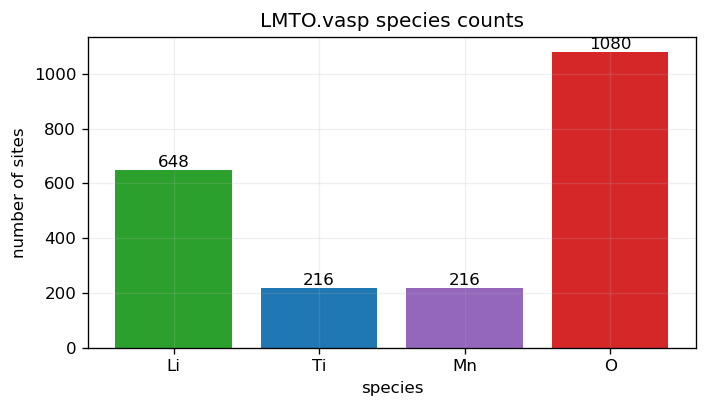

Lattice matrix (A):
 [[2.52000129e+01 0.00000000e+00 0.00000000e+00]
 [1.70000000e-15 2.81744709e+01 0.00000000e+00]
 [1.70000000e-15 4.50000000e-15 2.81744709e+01]]


In [1]:
from pathlib import Path
from collections import Counter
import json, subprocess, sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display
from pymatgen.core import Structure

from distortion_percolation.structure_analysis import (
    DEFAULT_OFFSET, DEFAULT_THRESHOLDS,
    load_structure_pair, nearest_cations, offset_centers,
)
from distortion_percolation.percolation_core import (
    connected_mobile_indices, structure_from_indices,
)
from tools.match_structures import match_structure
from tools.site_distortion import calculate

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.2})
perfect_file = Path('perfect.vasp')
observed_file = Path('LMTO.vasp')
output_dir = Path('notebook_outputs')
output_dir.mkdir(exist_ok=True)
perfect, observed = load_structure_pair(perfect_file, observed_file)

species_counts = Counter(site.specie.symbol for site in observed)
display(Markdown(
    f"**Reference:** `{perfect_file}` — {len(perfect)} sites, `{perfect.composition}`  \n"
    f"**Observed:** `{observed_file}` — {len(observed)} sites, `{observed.composition}`"
))
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(species_counts.keys(), species_counts.values(), color=['tab:green','tab:blue','tab:purple','tab:red'])
ax.set(title='LMTO.vasp species counts', xlabel='species', ylabel='number of sites')
for i, value in enumerate(species_counts.values()): ax.text(i, value, str(value), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print('Lattice matrix (A):\n', observed.lattice.matrix)

## 1. Map the distorted structure to the perfect lattice

Global Hungarian assignment is constrained by sublattice, not by the placeholder cation label in `perfect.vasp`.

**Mean mapping distance:** 0.2369 Å  
**Maximum mapping distance:** 0.7015 Å  
**Duplicate reference sites:** 0

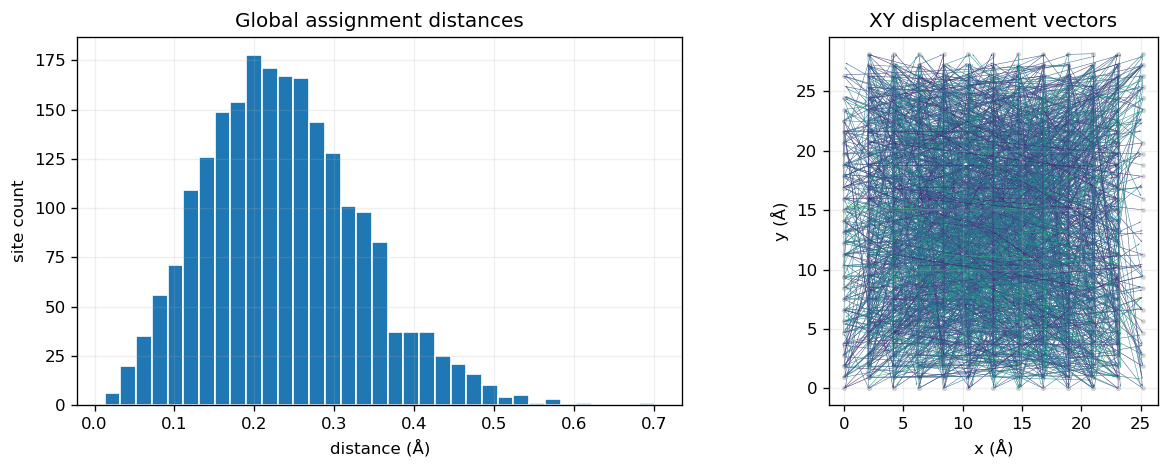

D:\Anaconda\Lib\site-packages\pymatgen\io\vasp\inputs.py:660: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="wt") as file:


'Li648 Ti216 Mn216 O1080\n1.0\n  25.2000128900000000    0.0000000000000000    0.0000000000000000\n   0.0000000000000017   28.1744709299999982    0.0000000000000000\n   0.0000000000000017    0.0000000000000045   28.1744709299999982\nLi Mn Li Mn Li Mn Li Ti Li Mn Li Mn Li Mn Li Ti Mn Li Ti Li Ti Li Ti Mn Li Mn Li Ti Li Mn Li Mn Li Ti Mn Li Mn Li Ti Li Ti Li Ti Li Mn Li Mn Li Mn Li Mn Li Mn Li Mn Li Mn Ti Li Ti Li Mn Li Mn Li Mn Li Ti Li Ti Li Ti Mn Li Ti Mn Ti Li Mn Li Mn Li Mn Li Mn Li Ti Li Mn Li Ti Li Mn Li Mn Ti Li Ti Li Mn Ti Li Mn Ti Li Ti Li Ti Mn Li Mn Li Ti Li Mn Li Ti Li Mn Li Mn Li Mn Li Ti Li Mn Li Mn Li Ti Li Mn Li Ti Li Mn Li Ti Li Mn Ti Li Ti Mn Ti Mn Li Ti Mn Li Ti Li Mn Li Mn Li Mn Li Ti Mn Li Ti Mn Li Mn Li Mn Li Mn Li Mn Li Mn Li Ti Li Mn Ti Li Ti Li Mn Li Mn Li Ti Li Mn Li Mn Li Ti Mn Li Mn Li Mn Li Ti Li Mn Li Mn Li Ti Li Mn Li Mn Li Mn Li Ti Li Ti Li Ti Mn Li Ti Li Mn Li Mn Li Mn Li Mn Li Ti Li Ti Li Mn Li Mn Ti Li Mn Li Ti Li Mn Li Ti Li Mn Ti Li Ti Mn Li Ti Li Mn 

In [2]:
matching_groups = [['Li', 'Ti', 'Mn'], ['O']]
mapped, mapping_report = match_structure(
    perfect, observed, species_policy='distorted', tolerance=None,
    species_groups=matching_groups,
)
assignment_distances = np.asarray([row['distance_A'] for row in mapping_report['assignments']])
display(Markdown(
    f"**Mean mapping distance:** {mapping_report['mean_distance_A']:.4f} Å  \n"
    f"**Maximum mapping distance:** {mapping_report['maximum_distance_A']:.4f} Å  \n"
    f"**Duplicate reference sites:** {mapping_report['duplicate_reference_sites']}"
))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(assignment_distances, bins=35, color='tab:blue', edgecolor='white')
axes[0].set(title='Global assignment distances', xlabel='distance (Å)', ylabel='site count')
axes[1].scatter(perfect.cart_coords[:,0], perfect.cart_coords[:,1], s=3, c='lightgray', label='perfect sites')
axes[1].quiver(
    perfect.cart_coords[:,0], perfect.cart_coords[:,1],
    observed.cart_coords[:,0] - mapped.cart_coords[:,0],
    observed.cart_coords[:,1] - mapped.cart_coords[:,1],
    assignment_distances, cmap='viridis', angles='xy', scale_units='xy', scale=1, width=.0015,
)
axes[1].set(title='XY displacement vectors', xlabel='x (Å)', ylabel='y (Å)', aspect='equal')
plt.tight_layout(); plt.show()
mapped.to(filename=output_dir / 'LMTO_mapped_to_perfect.vasp', fmt='poscar')

## 2. n-TM statistics on perfect-lattice tetrahedral centers

| n-TM | count | fraction |
|---:|---:|---:|
| 0 | 117 | 5.4167% |
| 1 | 831 | 38.4722% |
| 2 | 1013 | 46.8981% |
| 3 | 197 | 9.1204% |
| 4 | 2 | 0.0926% |

**Skipped centers:** 0

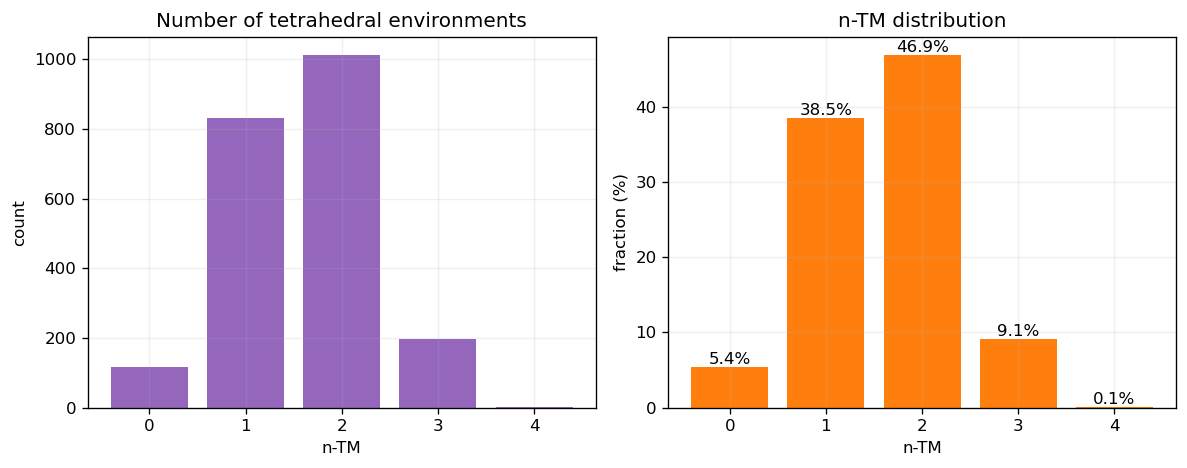

In [3]:
mobile_species = 'Li'
cation_species = ['Li', 'Ti', 'Mn']
tm_species = ['Ti', 'Mn']
centers = offset_centers(perfect, DEFAULT_OFFSET, 'cartesian')
n_tm_counts, skipped = Counter(), 0
for center in centers:
    neighbors = nearest_cations(observed, center, cation_species, radius=5.0, count=4)
    if len(neighbors) != 4:
        skipped += 1
        continue
    n_tm_counts[sum(site.specie.symbol in tm_species for site in neighbors)] += 1
total = sum(n_tm_counts.values())
counts = [n_tm_counts[n] for n in range(5)]
fractions = [value / total if total else 0 for value in counts]
rows = ['| n-TM | count | fraction |', '|---:|---:|---:|'] + [
    f'| {n} | {counts[n]} | {fractions[n]:.4%} |' for n in range(5)
]
display(Markdown('\n'.join(rows) + f'\n\n**Skipped centers:** {skipped}'))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(range(5), counts, color='tab:purple')
axes[0].set(title='Number of tetrahedral environments', xlabel='n-TM', ylabel='count', xticks=range(5))
axes[1].bar(range(5), np.asarray(fractions) * 100, color='tab:orange')
axes[1].set(title='n-TM distribution', xlabel='n-TM', ylabel='fraction (%)', xticks=range(5))
for i, value in enumerate(fractions): axes[1].text(i, value * 100, f'{value:.1%}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

## 3. Atomic displacement from `perfect.vasp`

The displacement assignment uses exact shortest Cartesian PBC distances. Cation grouping is required because the ideal file uses Mn as a generic cation-site label. The main reported value is the atom-weighted mean displacement of all Ti and Mn sites.

**Average transition-metal displacement (Ti + Mn): 0.2032 Å**

| species | sites | mean (Å) | std (Å) | maximum (Å) |
|---|---:|---:|---:|---:|
| Li | 648 | 0.2512 | 0.1056 | 0.7015 |
| Ti | 216 | 0.2291 | 0.0895 | 0.4836 |
| Mn | 216 | 0.1774 | 0.0737 | 0.4081 |
| O | 1080 | 0.2417 | 0.0938 | 0.5369 |

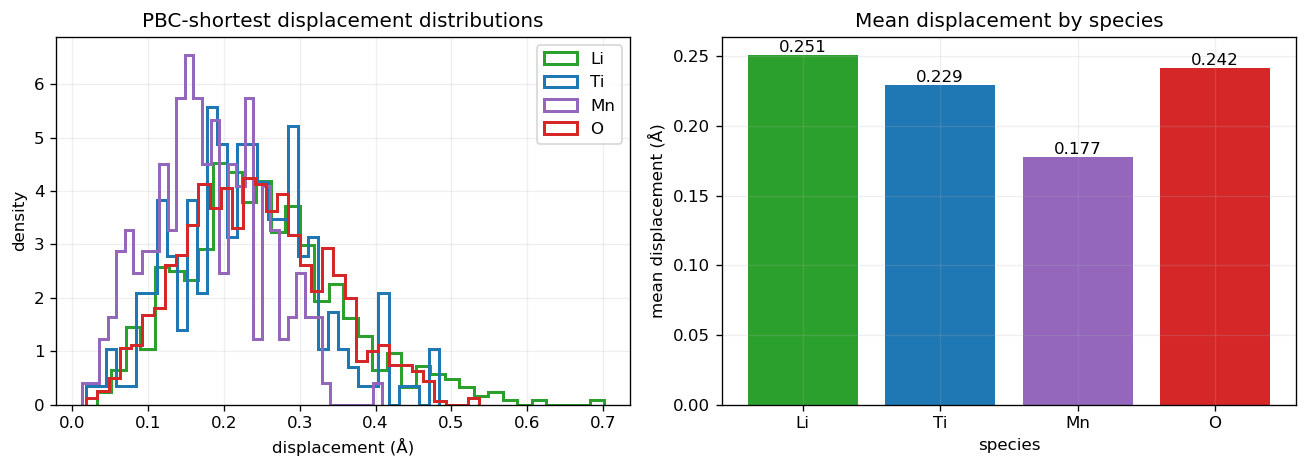

In [4]:
displacement = calculate(
    perfect, observed, species_constraint=False, species_groups=matching_groups
)
tm_distances = [
    value for symbol in tm_species
    for value in displacement.get(symbol, {}).get('all_distances', [])
]
summary_rows = ['| species | sites | mean (Å) | std (Å) | maximum (Å) |', '|---|---:|---:|---:|---:|']
for symbol in ['Li', 'Ti', 'Mn', 'O']:
    row = displacement[symbol]
    summary_rows.append(
        f"| {symbol} | {row['count']} | {row['mean_distance']:.4f} | {row['std_distance']:.4f} | {row['max_distance']:.4f} |"
    )
display(Markdown(
    f"**Average transition-metal displacement (Ti + Mn): {np.mean(tm_distances):.4f} Å**\n\n" + '\n'.join(summary_rows)
))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for symbol, color in zip(['Li','Ti','Mn','O'], ['tab:green','tab:blue','tab:purple','tab:red']):
    axes[0].hist(displacement[symbol]['all_distances'], bins=35, density=True, histtype='step', lw=1.8, label=symbol, color=color)
means = [displacement[s]['mean_distance'] for s in ['Li','Ti','Mn','O']]
axes[0].set(title='PBC-shortest displacement distributions', xlabel='displacement (Å)', ylabel='density'); axes[0].legend()
axes[1].bar(['Li','Ti','Mn','O'], means, color=['tab:green','tab:blue','tab:purple','tab:red'])
axes[1].set(title='Mean displacement by species', xlabel='species', ylabel='mean displacement (Å)')
for i, value in enumerate(means): axes[1].text(i, value, f'{value:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

## 4. High-n-TM local chemistry (3-TM and 4-TM only)

This section focuses on the relatively TM-rich tetrahedral environments. It reports the detailed Li/Ti/Mn compositions of 3-TM and 4-TM tetrahedra and the Ti/Mn fractions within those two classes.

| high-n-TM environment | count |
|---|---:|
| `3-TM:Li-Mn-Mn-Ti` | 83 |
| `3-TM:Li-Mn-Mn-Mn` | 51 |
| `3-TM:Li-Mn-Ti-Ti` | 48 |
| `3-TM:Li-Ti-Ti-Ti` | 15 |
| `4-TM:Mn-Mn-Mn-Ti` | 2 |

| class | tetrahedra | Ti fraction | Mn fraction |
|---:|---:|---:|---:|
| 3-TM | 197 | 0.3790 | 0.6210 |
| 4-TM | 2 | 0.2500 | 0.7500 |

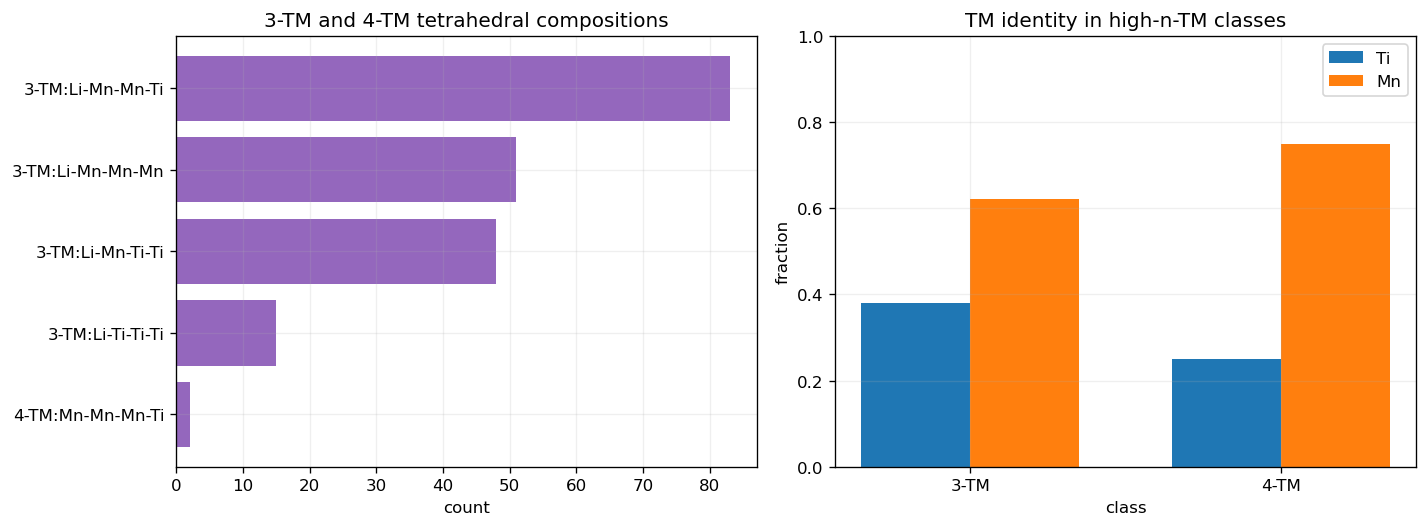

In [5]:
def run_tool(name, *arguments):
    command = [sys.executable, f'tools/{name}.py', *map(str, arguments)]
    result = subprocess.run(command, text=True, capture_output=True)
    if result.returncode:
        raise RuntimeError(result.stderr.strip() or f'{name} failed')
    return result

reports = {
    'environments': output_dir / 'tm_environments_3_4_tm.json',
    'tm_sites': output_dir / 'tm_site_statistics_3_4_tm.json',
}
run_tool('tm_environment', '--perfect', perfect_file, '--pattern', observed_file,
         '--cations', 'Li,Ti,Mn', '--classes', '3,4',
         '--output', reports['environments'], '--overwrite')
run_tool('tm_site_statistics', '--perfect', perfect_file, '--pattern', observed_file,
         '--tm-elements', 'Ti,Mn', '--classes', '3,4',
         '--output', reports['tm_sites'], '--overwrite')

environment_report = json.loads(reports['environments'].read_text())
site_report = json.loads(reports['tm_sites'].read_text())
environments = Counter(environment_report[0]['environments'])
rows = ['| high-n-TM environment | count |', '|---|---:|'] + [
    f'| `{name}` | {count} |' for name, count in environments.most_common()
]
summary = site_report['summary']
rows.extend([
    '', '| class | tetrahedra | Ti fraction | Mn fraction |', '|---:|---:|---:|---:|',
    *[f"| {n}-TM | {summary[str(n)]['site_count']} | {summary[str(n)]['probabilities']['Ti']:.4f} | {summary[str(n)]['probabilities']['Mn']:.4f} |" for n in (3, 4)],
])
display(Markdown('\n'.join(rows)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
items = list(reversed(environments.most_common()))
axes[0].barh([name for name, _ in items], [count for _, count in items], color='tab:purple')
axes[0].set(title='3-TM and 4-TM tetrahedral compositions', xlabel='count')
x = np.arange(2); width = .35
axes[1].bar(x - width/2, [summary[str(n)]['probabilities']['Ti'] for n in (3,4)], width, label='Ti')
axes[1].bar(x + width/2, [summary[str(n)]['probabilities']['Mn'] for n in (3,4)], width, label='Mn')
axes[1].set(title='TM identity in high-n-TM classes', xlabel='class', ylabel='fraction', xticks=x, xticklabels=['3-TM','4-TM'], ylim=(0,1)); axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Cation–oxygen bond-distance distributions

| bond | count | mean (Å) | variance (Å²) |
|---|---:|---:|---:|
| Li–O | 3888 | 2.1638 | 0.02810 |
| Mn–O | 1296 | 2.0712 | 0.02116 |
| Ti–O | 1296 | 2.0084 | 0.02091 |

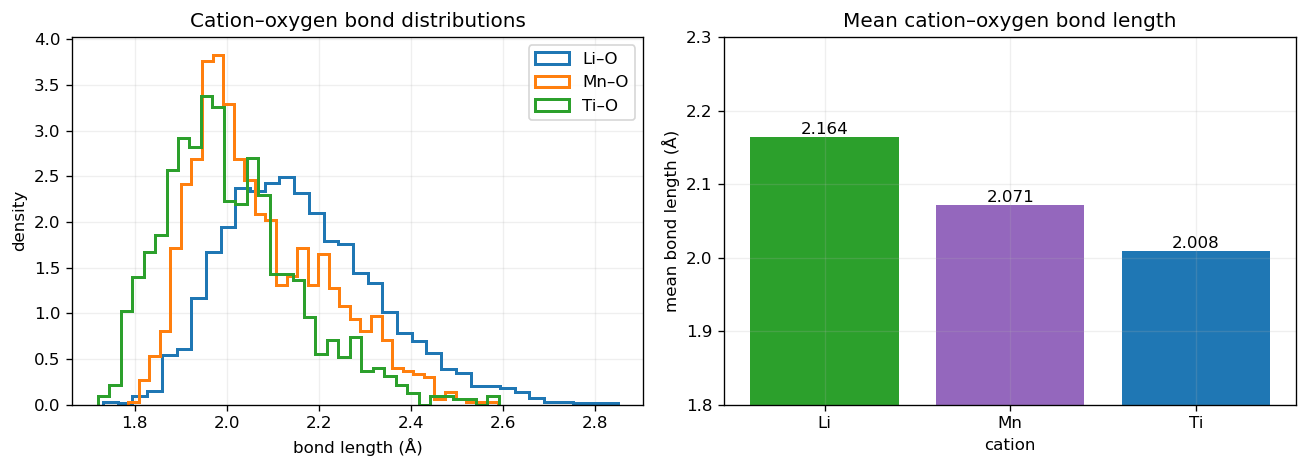

In [6]:
bond_json = output_dir / 'bond_distances.json'
bond_plot = output_dir / 'bond_distances.png'
run_tool('bond_distance', observed_file, '--cations', 'Li,Ti,Mn', '--output', bond_json, '--plot', bond_plot, '--overwrite')
bond_report = json.loads(bond_json.read_text())
bond_rows = ['| bond | count | mean (Å) | variance (Å²) |', '|---|---:|---:|---:|'] + [
    f"| {symbol}–O | {row['count']} | {row['mean']:.4f} | {row['variance']:.5f} |"
    for symbol, row in bond_report.items()
]
display(Markdown('\n'.join(bond_rows)))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for symbol, row in bond_report.items(): axes[0].hist(row['distances'], bins=35, density=True, histtype='step', lw=1.8, label=f'{symbol}–O')
axes[0].set(title='Cation–oxygen bond distributions', xlabel='bond length (Å)', ylabel='density'); axes[0].legend()
labels = list(bond_report)
axes[1].bar(labels, [bond_report[s]['mean'] for s in labels], color=['tab:green','tab:purple','tab:blue'])
axes[1].set(title='Mean cation–oxygen bond length', xlabel='cation', ylabel='mean bond length (Å)', ylim=(1.8,2.3))
for i, symbol in enumerate(labels): axes[1].text(i, bond_report[symbol]['mean'], f"{bond_report[symbol]['mean']:.3f}", ha='center', va='bottom')
plt.tight_layout(); plt.show()

## 6. 0-TM and 0+1-TM channel coverage

The 1-TM selection uses the Mn and Ti height thresholds defined in the repository. In addition to the selected-site counts, this section reports the **channel coverage fraction**: the number of unique Li sites admitted by each channel definition divided by all Li sites in `LMTO.vasp`. This is a site-coverage metric; it should not be confused with a separate graph-based proof of periodic percolation.

D:\Anaconda\Lib\site-packages\pymatgen\core\structure.py:3175: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt", errors="replace") as file:


**Total Li sites:** 648

| channel selection | unique Li sites | fraction of all Li |
|---|---:|---:|
| 0-TM only | 344 | 53.09% |
| added by qualified 1-TM | 93 | 14.35% |
| 0-TM + 1-TM | 437 | 67.44% |

Measured **831** 1-TM tetrahedra.

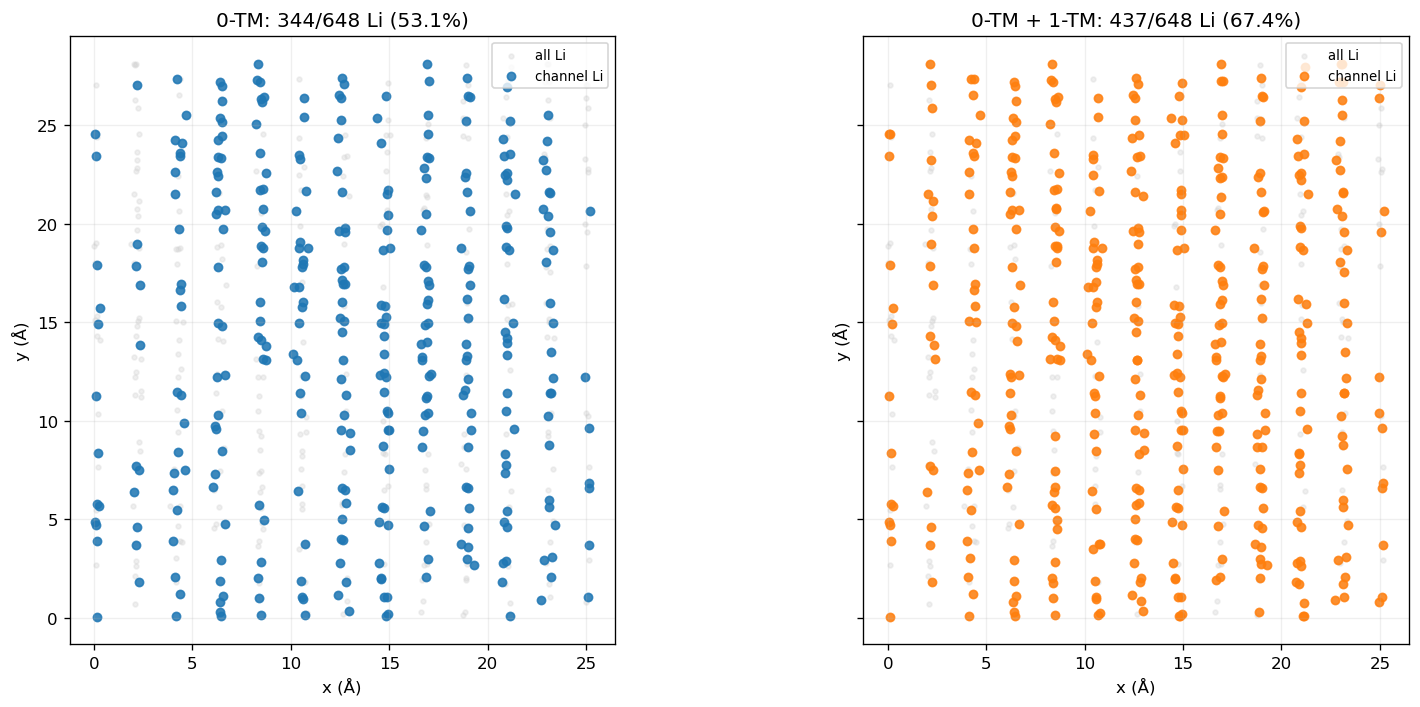

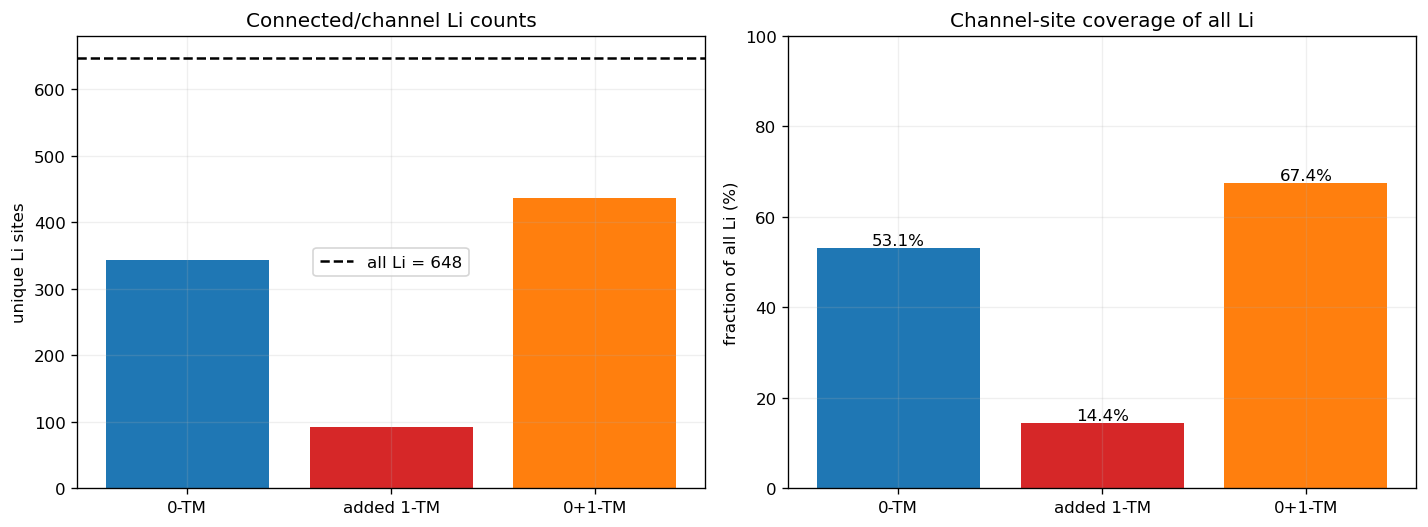

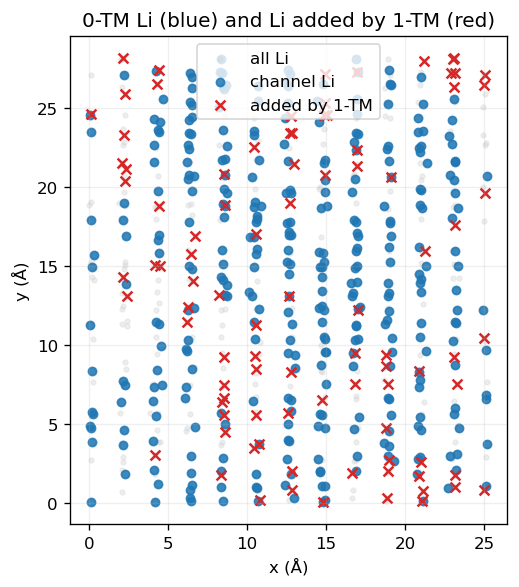

In [7]:
zero_tm, _ = connected_mobile_indices(
    observed_file, centers, mobile_species='Li', cation_species=cation_species,
    tm_thresholds={}, include_zero_tm=True, include_one_tm=False,
)
zero_and_one_tm, one_tm_observations = connected_mobile_indices(
    observed_file, centers, mobile_species='Li', cation_species=cation_species,
    tm_thresholds=DEFAULT_THRESHOLDS,
    include_zero_tm=True, include_one_tm=True,
)
qualified_one_tm = zero_and_one_tm - zero_tm
total_li = sum(site.specie.symbol == 'Li' for site in observed)
zero_fraction = len(zero_tm) / total_li
combined_fraction = len(zero_and_one_tm) / total_li
added_fraction = len(qualified_one_tm) / total_li

display(Markdown(
    f"**Total Li sites:** {total_li}\n\n"
    f"| channel selection | unique Li sites | fraction of all Li |\n|---|---:|---:|\n"
    f"| 0-TM only | {len(zero_tm)} | {zero_fraction:.2%} |\n"
    f"| added by qualified 1-TM | {len(qualified_one_tm)} | {added_fraction:.2%} |\n"
    f"| 0-TM + 1-TM | {len(zero_and_one_tm)} | {combined_fraction:.2%} |\n\n"
    f"Measured **{len(one_tm_observations)}** 1-TM tetrahedra."
))

def projection(ax, indices, title, color):
    li_indices = [i for i, site in enumerate(observed) if site.specie.symbol == 'Li']
    background = observed.cart_coords[li_indices]
    selected = observed.cart_coords[sorted(indices)] if indices else np.empty((0, 3))
    ax.scatter(background[:,0], background[:,1], s=8, c='lightgray', alpha=.35, label='all Li')
    ax.scatter(selected[:,0], selected[:,1], s=24, c=color, alpha=.85, label='channel Li')
    ax.set(title=title, xlabel='x (Å)', ylabel='y (Å)', aspect='equal'); ax.legend(loc='upper right', fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
projection(axes[0], zero_tm, f'0-TM: {len(zero_tm)}/{total_li} Li ({zero_fraction:.1%})', 'tab:blue')
projection(axes[1], zero_and_one_tm, f'0-TM + 1-TM: {len(zero_and_one_tm)}/{total_li} Li ({combined_fraction:.1%})', 'tab:orange')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(['0-TM', 'added 1-TM', '0+1-TM'], [len(zero_tm), len(qualified_one_tm), len(zero_and_one_tm)], color=['tab:blue','tab:red','tab:orange'])
axes[0].axhline(total_li, color='black', ls='--', label=f'all Li = {total_li}')
axes[0].set(title='Connected/channel Li counts', ylabel='unique Li sites'); axes[0].legend()
axes[1].bar(['0-TM', 'added 1-TM', '0+1-TM'], np.asarray([zero_fraction, added_fraction, combined_fraction]) * 100, color=['tab:blue','tab:red','tab:orange'])
axes[1].set(title='Channel-site coverage of all Li', ylabel='fraction of all Li (%)', ylim=(0,100))
for i, value in enumerate([zero_fraction, added_fraction, combined_fraction]): axes[1].text(i, value*100, f'{value:.1%}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
projection(ax, zero_tm, '0-TM Li (blue) and Li added by 1-TM (red)', 'tab:blue')
extra = observed.cart_coords[sorted(qualified_one_tm)]
ax.scatter(extra[:,0], extra[:,1], s=35, c='tab:red', marker='x', label='added by 1-TM')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Warren–Cowley short-range order (WCP)

WCP analyzes chemical occupations in `LMTO.vasp`; it does **not** use perfect coordinates. The native implementation below uses each cation's 12 nearest cation neighbors under PBC. For directed pair A→B, $\alpha_{AB}=1-P(B\mid A)/c_B$: zero is random mixing, positive indicates avoidance, and negative indicates preference.

**Cation concentrations:** Li=0.600, Mn=0.200, Ti=0.200

| center A → neighbor B | Li | Mn | Ti |
|---|---:|---:|---:|
| Li | 0.0981 | -0.0963 | -0.1979 |
| Mn | -0.0963 | 0.0316 | 0.2573 |
| Ti | -0.1979 | 0.2573 | 0.3364 |

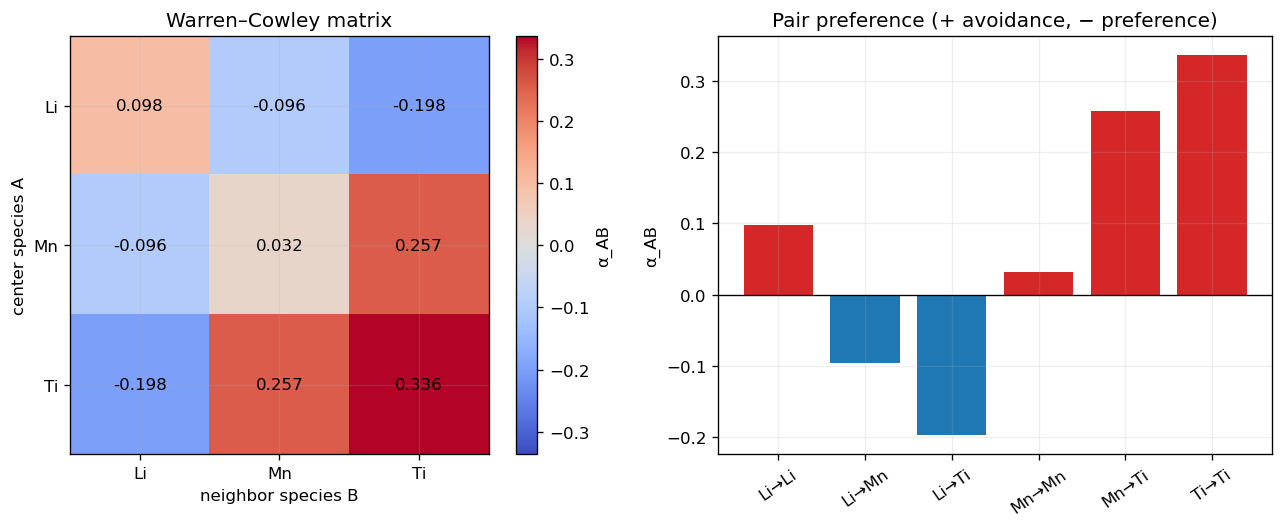

In [8]:
wcp_json = output_dir / 'warren_cowley.json'
run_tool('warren_cowley', observed_file, '--backend', 'native', '--species', 'Li,Ti,Mn',
         '--neighbors', '12', '--output', wcp_json, '--overwrite')
wcp = json.loads(wcp_json.read_text())
labels = wcp['selected_species']
wcp_matrix = np.asarray([[wcp['parameters'][a][b] for b in labels] for a in labels])
wcp_rows = ['| center A → neighbor B | ' + ' | '.join(labels) + ' |', '|---|' + '---:|' * len(labels)]
for i, label in enumerate(labels): wcp_rows.append('| ' + label + ' | ' + ' | '.join(f'{value:.4f}' for value in wcp_matrix[i]) + ' |')
display(Markdown(
    '**Cation concentrations:** ' + ', '.join(f"{key}={value:.3f}" for key, value in wcp['concentrations'].items()) + '\n\n' + '\n'.join(wcp_rows)
))
limit = np.max(np.abs(wcp_matrix))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
image = axes[0].imshow(wcp_matrix, cmap='coolwarm', vmin=-limit, vmax=limit)
axes[0].set_xticks(range(len(labels)), labels=labels); axes[0].set_yticks(range(len(labels)), labels=labels)
axes[0].set(title='Warren–Cowley matrix', xlabel='neighbor species B', ylabel='center species A')
for i in range(len(labels)):
    for j in range(len(labels)): axes[0].text(j, i, f'{wcp_matrix[i,j]:.3f}', ha='center', va='center')
fig.colorbar(image, ax=axes[0], label='α_AB')
pairs, values = [], []
for i, a in enumerate(labels):
    for j, b in enumerate(labels):
        if j >= i: pairs.append(f'{a}→{b}'); values.append(wcp_matrix[i,j])
axes[1].bar(pairs, values, color=['tab:red' if value > 0 else 'tab:blue' for value in values])
axes[1].axhline(0, color='black', lw=.8)
axes[1].set(title='Pair preference (+ avoidance, − preference)', ylabel='α_AB'); axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.show()

## Citation and acknowledgments

If you use this DRX–Distortion–Percolation workflow, please cite:

> Zichang Zhang, Lihua Feng, Jiewei Cheng, Peng-Hu Du, Chu-Liang Fu, Xintao Long, Anchun Tang, Longlong Fan, Kang Dong, Haoyu Wu, Weihan Li, Jian Peng, Shuo Wang, Dingguo Xia, Xueliang Sun, and Qiang Sun. **Interplay of Lattice Distortion and Cation Disorder Governs Li-Ion Transport in Cation-Disordered Rocksalt Cathodes.** *Journal of the American Chemical Society* (2026). [https://doi.org/10.1021/jacs.6c05378](https://doi.org/10.1021/jacs.6c05378)

This work was partially supported by grants from the National Key Research and Development Program of China (2022YFB2502100), the National Natural Science Foundation of China (92372112, 22373005, 52573249), and the Commanding Heights of Science and Technology of Chinese Academy of Sciences (LDES15 0000). The calculations were supported by the High-performance Computing Platform of Peking University and Eastern Institute of Technology, Ningbo.

## Execution provenance

The following record is generated during a successful end-to-end run and remains embedded in the committed notebook for GitHub rendering.

In [9]:
from datetime import datetime, timezone
execution_record = {
    'analysis': 'DRX-Distortion-Percolation',
    'status': 'completed',
    'executed_at_utc': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'python': sys.version.split()[0],
    'reference': str(perfect_file),
    'observed': str(observed_file),
    'code_cells_completed': 9,
}
display(Markdown(
    '### ✅ DRX–Distortion–Percolation notebook completed\n\n' +
    '\n'.join(f'- **{key}:** `{value}`' for key, value in execution_record.items())
))
(output_dir / 'execution_record.json').write_text(json.dumps(execution_record, indent=2), encoding='utf-8')

### ✅ DRX–Distortion–Percolation notebook completed

- **analysis:** `DRX-Distortion-Percolation`
- **status:** `completed`
- **executed_at_utc:** `2026-08-23T05:09:08+00:00`
- **python:** `3.12.7`
- **reference:** `perfect.vasp`
- **observed:** `LMTO.vasp`
- **code_cells_completed:** `9`

230

## Analysis coverage

This notebook exercises reference mapping, n-TM fractions, the atom-weighted mean Ti/Mn displacement, 3-TM and 4-TM local chemistry, cation–oxygen bond lengths, 0-TM and 0+1-TM Li-channel coverage (counts and fractions of all Li), and native Warren–Cowley short-range order. The redundant fixed-cutoff graph-connectivity section has been removed so the channel analysis is reported once, with its assumptions explicit.